# 14章 アプリケーションとデータ転送

本章では、スイッチやルータなどの通信機器におけるパケットの転送順序について扱います。前章までは複数の通信装置間で連携するためのプロトコルや手順を扱ってきましたが、ここで一度、通信装置内部の動作の理解に移行します。一つの通信ノードや回線を多数のアプリケーションが共用するとき、リアルタイム性の高い通信を優先させたり、公平に扱ったりしたい，というケースがあります。そういったとき、通信機器内のメモリに保存されたパケットをどのような順番で読み出して送出するか、が重要です。本章では、こうした仕組みを扱うための「待ち行列」という考え方と、遅延などの通信品質について、実装しながら学んでいきます。

## 待ち行列

### 待ち行列とは

「待ち行列」とは、お店の行列と同じで「到着するデータ（パケット）をどのように待たせるか」を抽象的なモデルで表したものです。本章で急にこのような抽象的な話題が出てきたのは、ネットワークリソースの有限性が重要な問題になるからです。通信パケットを処理するためには、ネットワークの帯域などのリソースを、少しの時間だけ占有して使用する必要があります。一般的にリソースが潤沢にあるに越したことはないのですが、そのためには非常に大きなコストがかかります。したがって、制限のあるリソースを上手に使うことは非常に重要な問題です。

たくさんのユーザやアプリケーションからの要求を効率的に処理することは古典的かつ重要な問題です。例えば、リアルタイム系サービスでは応答時間を非常に短くする必要があるなど、アプリケーションごとに異なる要求条件があるため、うまくパケットを待たせたる（あるいは待たせない）必要があるのです。



今度は、それぞれの待ち行列でまったく挙動が違うことが分かります。キュー0, 1に対しては、どんどんデータが蓄積していく一方で、キュー2では蓄積量は少なめにとどまり、キュー3に至っては待ち行列のサイズはほぼずっとゼロです。この結果は、各キューに対する入力データ量の違いをそのまま反映しています。つまり、キューあたりの見かけ上の出力速度は、合計出力速度を4等分した約0.25Mbpsになるため、データ入力頻度が高いキューほど、データの蓄積速度が速くなるのです。


Cloning into 'network-simulator'...
remote: Enumerating objects: 2680, done.
remote: Counting objects: 100% (877/877), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 2680 (delta 814), reused 793 (delta 763), pack-reused 1803 (from 2)
Receiving objects: 100% (2680/2680), 787.92 KiB | 18.32 MiB/s, done.
Resolving deltas: 100% (2001/2001), done.
/content/network-simulator/network-simulator/network-simulator/network-simulator


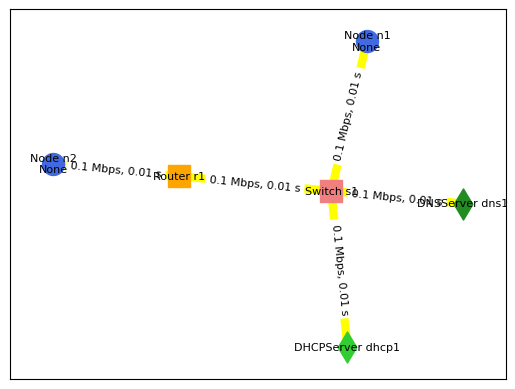

Initiating TCP handshake: Sending SYN to 192.168.1.1/24:21
Sending TCP packet to 192.168.1.1/24:21 Flags: SYN Seq:None Ack:None
Processing TCP packet from 192.168.2.1/24:1024 to 192.168.1.1/24:21
TCP flags: SYN
Sending TCP packet to 192.168.2.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
Processing TCP packet from 192.168.1.1/24:21 to 192.168.2.1/24:1024
TCP flags: SYN,ACK
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 21)
on_connection_established ('192.168.1.1/24', 21) FTP
Sending TCP packet to 192.168.1.1/24:21 Flags: ACK Seq:5306 Ack:1
Processing TCP packet from 192.168.2.1/24:1024 to 192.168.1.1/24:21
TCP flags: ACK
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 1024)
on_connection_established ('192.168.2.1/24', 1024) None
[FTPServer] Connection established. Sending 220 greeting.
[FTPServer] Sending response: 220 Service ready
Sending TCP packet to 192.168.2.1/24:1024 Flags: ACK Seq:0 Ack:0
[DEBUG] handle_acknowledgement for ('192.168.2.1/24', 

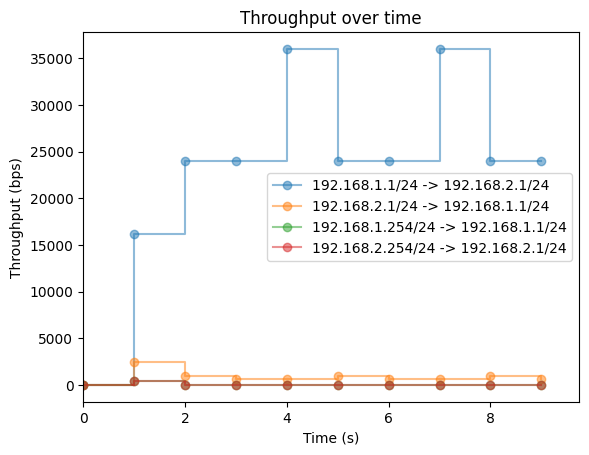

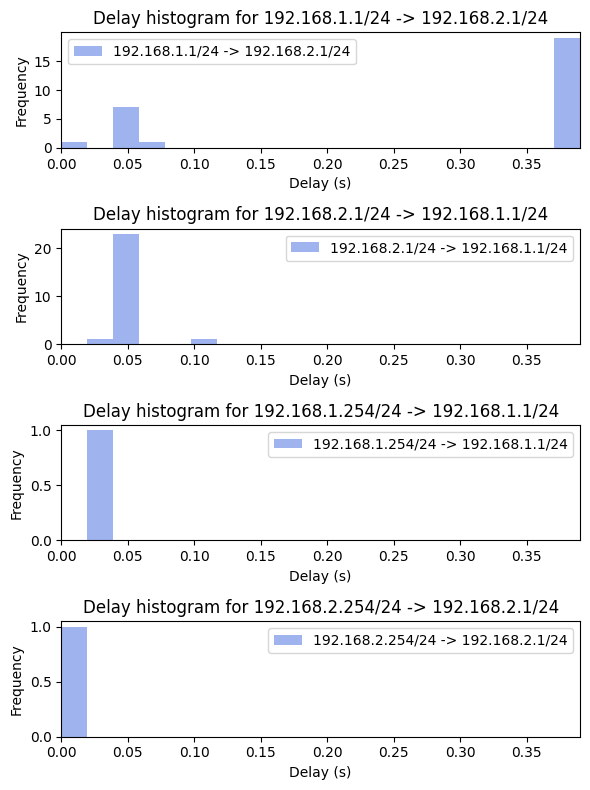

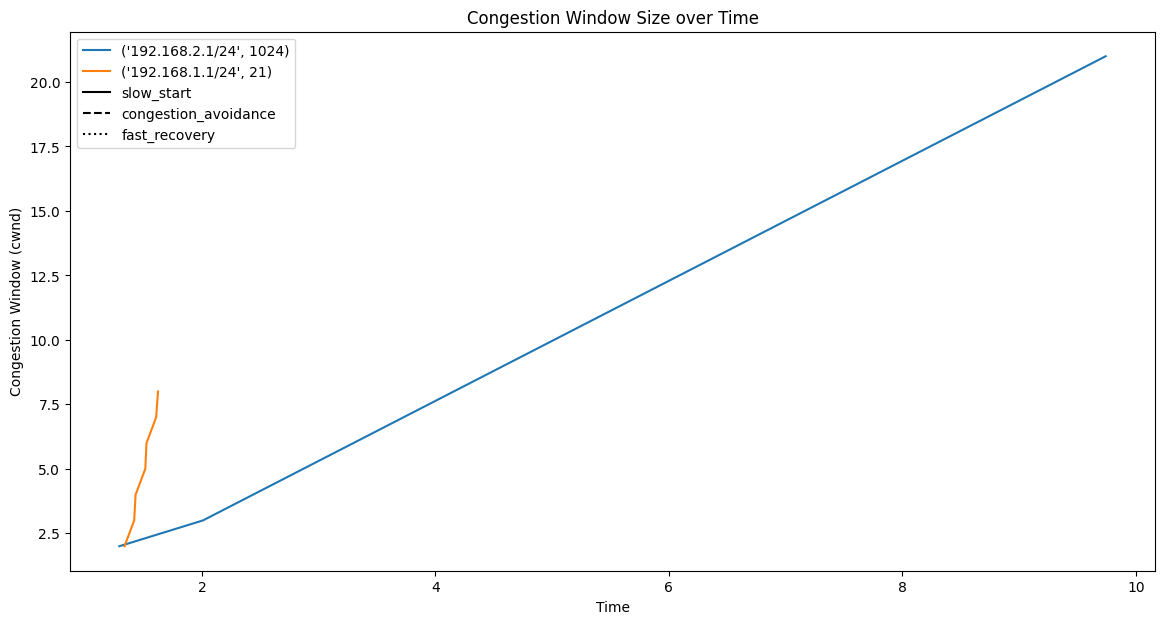

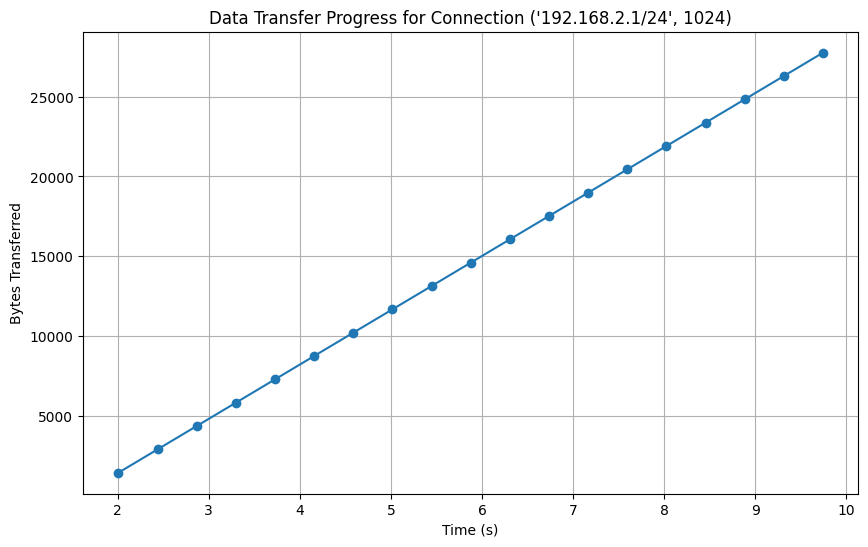

In [4]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
%cd network-simulator

from sec14a.NetworkEventScheduler import NetworkEventScheduler
from sec14a.Node import Node
from sec14a.Switch import Switch
from sec14a.Router import Router
from sec14a.Server import DNSServer, DHCPServer
from sec14a.Link import Link
from sec14a.Application import DnsClient, DhcpClient, UDPApp, FTPClient, FTPServer

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True, link_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.01, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)


# FTPトラフィック設定
ftp_server = FTPServer(node1, shared_files={}, verbose=True)  # FTPサーバインスタンス
node1.register_application(21, "TCP", ftp_server)  # 21/TCPポートでFTPサーバを起動（待ち受け）
ftp_client = FTPClient(node2, verbose=False)  # FTPクライアントインスタンス
node2.register_application(0, "TCP", ftp_client)  # FTPクライアントをApplicationManagerに登録

# ファイル読み込み（サーバ側ファイル想定）
file_path = 'data/cat.jpg'
with open(file_path, 'rb') as f:
    file_data = f.read()
ftp_server.shared_files["cat.jpg"] = file_data  # サーバにファイル登録

# クライアント側でFTP転送を開始する処理
def start_ftp_transfer():
    ftp_client.connect(server_ip="192.168.1.1/24", server_port=21)
    ftp_client.retrieve_file("cat.jpg")
nes.schedule_event(1.0, start_ftp_transfer)

# UDP送信アプリケーションのインスタンス作成
#udp_app = UDPApp(node1)
#def start_udp_traffic():
#    udp_app.start_traffic(destination_url="www.example.com", bitrate=100000, start_time=2.0, duration=5.0, header_size=28, payload_size=1000, burstiness=1.0, dscp=16)
#nes.schedule_event(2.0, start_udp_traffic)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)

# 転送進行状況のプロット
nes.plot_cwnd_log()
ftp_connections = [ck for ck, info in node1.tcp_connections.items() if info.get('transfer_info') and info['transfer_info'].get('progress')]
if ftp_connections:
    connection_key = ftp_connections[0]
    nes.plot_transfer_progress(node1, connection_key)

Cloning into 'network-simulator'...
remote: Enumerating objects: 2698, done.
remote: Counting objects: 100% (895/895), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 2698 (delta 819), reused 807 (delta 763), pack-reused 1803 (from 2)
Receiving objects: 100% (2698/2698), 867.20 KiB | 15.49 MiB/s, done.
Resolving deltas: 100% (2006/2006), done.
/content/network-simulator/network-simulator/network-simulator/network-simulator/network-simulator


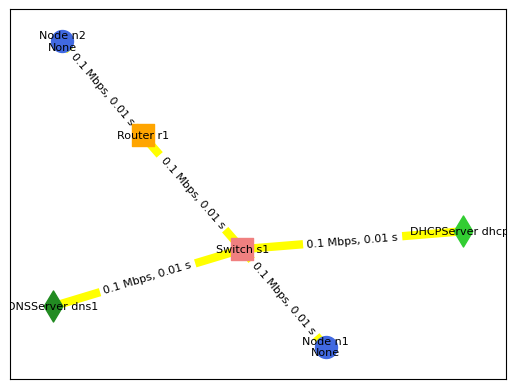

Node n1 sending DHCP DISCOVER (attempt 1/3)
DHCP Server dhcp1 offering IP 192.168.1.1/24 to client 5b:41:8a:e6:28:3e
Node n1 sending DHCP REQUEST for IP 192.168.1.1/24
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
Node n1 sending DNS query for www.example.com
DNS resolved: www.example.com -> 192.168.2.1/24
[HTTPClient] Requesting TCP connect to 192.168.2.1/24 80
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:80
[HTTPClient] Will retrieve file after connection: index.html
Sending TCP packet to 192.168.2.1/24:80 Flags: SYN Seq:None Ack:None
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:80
TCP flags: SYN
Sending TCP packet to 192.168.1.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
Processing TCP packet from 192.168.2.1/24:80 to 192.168.1.1/24:1024
TCP flags: SYN,ACK
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 80)
on_connection_established ('192.168.2.1/24', 80) 

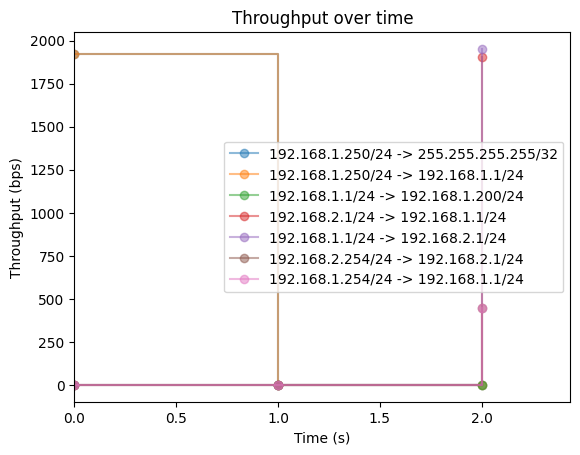

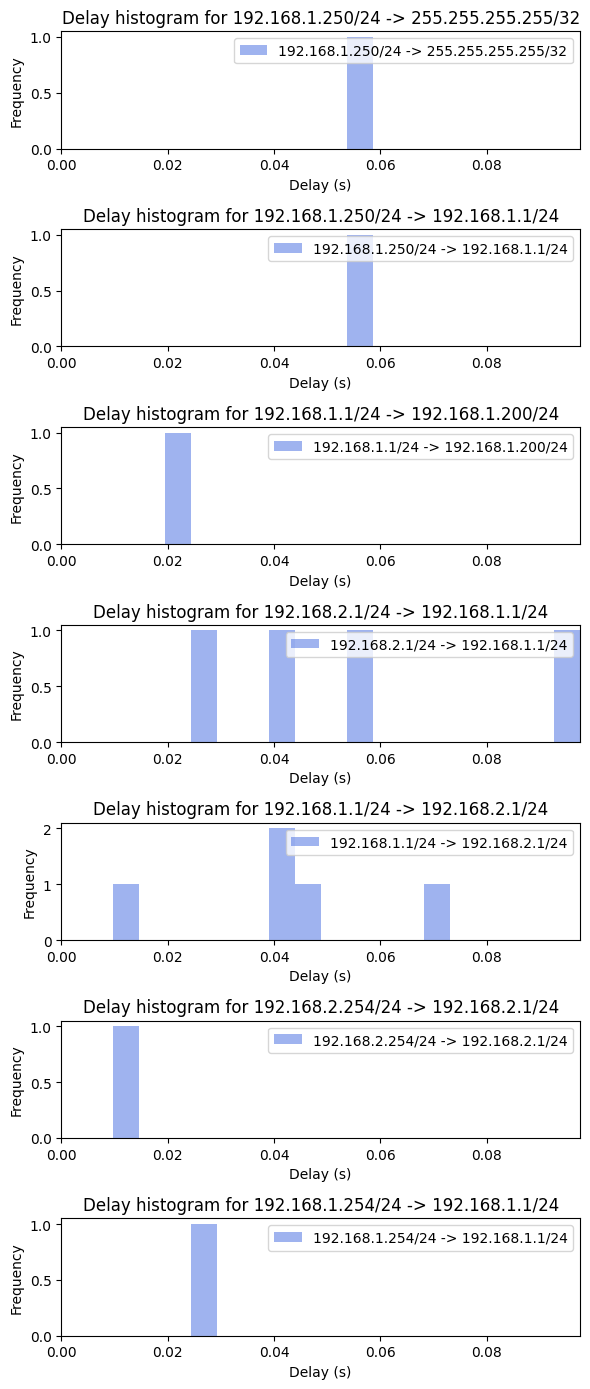

In [5]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
%cd network-simulator

from sec14b.NetworkEventScheduler import NetworkEventScheduler
from sec14b.Node import Node
from sec14b.Switch import Switch
from sec14b.Router import Router
from sec14b.Server import DNSServer, DHCPServer
from sec14b.Link import Link
from sec14b.Application import DnsClient, DhcpClient, UDPApp, FTPClient, FTPServer, HTTPClient, HTTPServer

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True, link_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# HTTPサーバの設定
shared_files = {
    "index.html": b"Welcome to example.com!",
    "test.txt": b"This is a test file.",
    "large.dat": b"X" * 10000  # 10KB file for testing
}
http_server = HTTPServer(node2, shared_files, verbose=True)
node2.application_layer.register_http_server(http_server)

# HTTPクライアントの設定
http_client = HTTPClient(node1, verbose=True)
node1.application_layer.register_http_client(http_client)

def start_http_download():
    # DNSで名前解決してからHTTP GETを実行
    def on_dns_resolved(resolved_ip):
        http_client.connect(resolved_ip)
        http_client.get_file("index.html")

    node1.application_layer.resolve_destination_url("www.example.com", callback=on_dns_resolved)

# HTTPダウンロードを2秒後に開始
nes.schedule_event(2.0, start_http_download)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)
#nes.plot_cwnd_log()


### 演習課題1: 優先制御の確認

#### 目的
パケットの優先度による完全優先制御の挙動の確認。

#### 課題の概要
トラフィックのDSCP値を増減させながら、パケットを送受信してみましょう。
DSCP値が高い、すなわち優先度が高いパケットが優先的に転送され、優先度が低いパケットの遅延が増大することを確認しましょう。

### 演習課題2: ラウンドロビンキューの実装

#### 目的
ラウンドロビンキューをシミュレータに実装し、公平制御について理解する。

#### 課題
完全優先制御の代わりに、ラウンドロビンでパケットを読み出して出力するキューを実装してみましょう。


## 本章のまとめ

本章では、パケットのキューイングとスケジューリングを扱いました。
待ち行列とキューおよびスケジューラの概念を学習し、シンプルなシミュレーションによって待ち時間やキュー長について学びました。
また優先制御やラウンドロビンといった基本的な手法についても確認しました。
その上で、優先度を表すフィールドをパケットに付与できるようにシミュレータをアップデートし、優先制御を実装しました。
各アプリケーションの通信品質すなわちスループットや遅延に対して、特に混雑時には優先制御が与える影響が大きいことが理解できたかと思います。
